In [2]:
# ============================================================
# Descriptor analysis from XYZ files
# - Pure RDKit XYZ parsing
# - Count linker atoms using fragments from SDF
# - Generate violin plots for every property by run mode
# ============================================================

import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from rdkit import Chem
from rdkit.Chem import (
    Descriptors,
    QED,
    rdMolDescriptors,
    RDConfig,
    rdDetermineBonds,
)

# ------------------------------------------------------------
# SA score import
# ------------------------------------------------------------
sys.path.append(os.path.join(RDConfig.RDContribDir, "SA_Score"))
import sascorer

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
MODE_DIRS = {
    "geom": Path("final_R_NA_NP_2/"),
    "pocket": Path("final_R_NA_P_1/"),
    "pocket_anchor": Path("final_R_A_P_1/"),
}

MODE_ORDER = ["geom", "pocket", "pocket_anchor"]

MODE_LABELS = {
    "geom": "Geom (no pocket)",
    "pocket": "Pocket (no anchor)",
    "pocket_anchor": "Pocket + Anchor",
}

MODE_COLORS = {
    "geom": "#4C72B0",
    "pocket": "#DD8452",
    "pocket_anchor": "#55A868",
}

FRAGMENT_SDF = Path("Fragments.sdf")

# Filters
FILTER_LOGP_MIN = -2.0
FILTER_LOGP_MAX = 5.0
FILTER_SA_MAX = 6.5
FILTER_QED_MIN = 0.15

# Properties
VIOLIN_PROPS = [
    "MW",
    "LogP",
    "HBD",
    "HBA",
    "TPSA",
    "RotBonds",
    "RingCount",
    "QED",
    "SA",
    "LinkerHA",
]

# Output folder
OUT_DIR = Path("violin_plots_2")
OUT_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# STEP 1: Load fragments
# ------------------------------------------------------------
def load_fragments_from_sdf(sdf_path):
    suppl = Chem.SDMolSupplier(str(sdf_path), removeHs=False)

    frags = []

    for mol in suppl:
        if mol is None:
            continue

        try:
            frags.append(Chem.RemoveHs(mol))
        except:
            frags.append(mol)

    return frags


frag_mols = load_fragments_from_sdf(FRAGMENT_SDF)

print(f"Loaded {len(frag_mols)} fragments")

if len(frag_mols) == 0:
    raise ValueError("No valid fragments found")


# ------------------------------------------------------------
# STEP 2: XYZ -> RDKit molecule
# ------------------------------------------------------------
def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None, None

        # Connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except Exception as e:
            print(f"Bond-order warning ({xyz_path.name}): {e}")

        # Sanitize carefully
        try:
            Chem.SanitizeMol(mol)
        except Exception as e:
            print(f"Sanitize warning ({xyz_path.name}): {e}")

        smiles = Chem.MolToSmiles(mol)

        return mol, smiles

    except Exception as e:
        print(f"Failed: {xyz_path.name} | {e}")
        return None, None


# ------------------------------------------------------------
# STEP 3: Linker heavy atoms
# ------------------------------------------------------------
def count_linker_atoms(mol):

    total_ha = mol.GetNumHeavyAtoms()

    matched_atoms = set()

    for frag in frag_mols:

        try:
            matches = mol.GetSubstructMatches(frag)

            if matches:
                for atom_idx in matches[0]:
                    matched_atoms.add(atom_idx)

        except:
            continue

    if matched_atoms:
        return max(0, total_ha - len(matched_atoms))

    frag_ha = sum(f.GetNumHeavyAtoms() for f in frag_mols)

    return max(0, total_ha - frag_ha)


# ------------------------------------------------------------
# STEP 4: Property calculation
# ------------------------------------------------------------
def calc_props(mol, smiles):

    try:

        return {
            "MW": Descriptors.ExactMolWt(mol),
            "LogP": Descriptors.MolLogP(mol),
            "HBD": rdMolDescriptors.CalcNumHBD(mol),
            "HBA": rdMolDescriptors.CalcNumHBA(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "RotBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
            "RingCount": rdMolDescriptors.CalcNumRings(mol),
            "QED": QED.qed(mol),
            "SA": sascorer.calculateScore(mol),
            "LinkerHA": count_linker_atoms(mol),
            "smiles": smiles,
        }

    except Exception as e:

        print(f"Descriptor failed: {smiles} | {e}")
        return None


# ------------------------------------------------------------
# STEP 5: Load all molecules
# ------------------------------------------------------------
records = []

for mode, xyz_dir in MODE_DIRS.items():

    xyz_files = sorted(xyz_dir.glob("*.xyz"))

    print(f"\n[{mode}] Found {len(xyz_files)} xyz files")

    ok = 0
    fail = 0

    for xyz_path in xyz_files:

        mol, smiles = xyz_to_mol(xyz_path)

        if mol is None:
            fail += 1
            continue

        props = calc_props(mol, smiles)

        if props is None:
            fail += 1
            continue

        props["mode"] = mode
        props["file"] = xyz_path.name

        records.append(props)

        ok += 1

    print(f"OK = {ok} | FAIL = {fail}")

df = pd.DataFrame(records)

print("\nTotal molecules:", len(df))

if len(df) == 0:
    raise ValueError("No valid molecules loaded")


# ------------------------------------------------------------
# STEP 6: Filtering
# ------------------------------------------------------------
df_f = df[
    (df["LogP"] >= FILTER_LOGP_MIN)
    & (df["LogP"] <= FILTER_LOGP_MAX)
    & (df["SA"] <= FILTER_SA_MAX)
    & (df["QED"] >= FILTER_QED_MIN)
].copy()

print("\nAfter filtering:")
print(df_f.groupby("mode").size())


# ------------------------------------------------------------
# STEP 7: Violin plots
# ------------------------------------------------------------
def plot_violin_property(df_in, prop):

    fig, ax = plt.subplots(figsize=(8, 5))

    data = []
    labels = []
    colors = []

    valid_modes = []

    for mode in MODE_ORDER:

        vals = df_in[df_in["mode"] == mode][prop].dropna().values

        if len(vals) == 0:
            continue

        data.append(vals)
        labels.append(MODE_LABELS[mode])
        colors.append(MODE_COLORS[mode])
        valid_modes.append(mode)

    if len(data) == 0:
        print(f"No data for {prop}")
        return

    vp = ax.violinplot(
        data,
        showmeans=True,
        showmedians=True,
        showextrema=True,
    )

    # violin styling
    for body, color in zip(vp["bodies"], colors):
        body.set_facecolor(color)
        body.set_edgecolor("black")
        body.set_alpha(0.75)

    for part in ["cbars", "cmins", "cmaxes", "cmeans", "cmedians"]:
        if part in vp:
            vp[part].set_edgecolor("black")
            vp[part].set_linewidth(1)

    # scatter overlay
    for i, (mode, color) in enumerate(zip(valid_modes, colors), start=1):

        vals = df_in[df_in["mode"] == mode][prop].dropna().values

        x = np.random.normal(i, 0.05, size=len(vals))

        ax.scatter(
            x,
            vals,
            s=10,
            alpha=0.35,
            color=color,
            edgecolors="none",
        )

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=15)

    ax.set_ylabel(prop)
    ax.set_title(f"{prop} distribution by run mode")

    ax.grid(axis="y", linestyle="--", alpha=0.35)

    plt.tight_layout()

    out_path = OUT_DIR / f"violin_{prop}.png"

    plt.savefig(out_path, dpi=300, bbox_inches="tight")

    plt.show()

    print(f"Saved: {out_path}")


# Generate violin plots
for prop in VIOLIN_PROPS:
    plot_violin_property(df_f, prop)


# ------------------------------------------------------------
# STEP 8: Save tables
# ------------------------------------------------------------
df.to_csv("molecule_descriptors_all.csv", index=False)
df_f.to_csv("molecule_descriptors_filtered.csv", index=False)

print("\nSaved descriptor tables")

Saved: violin_plots/violin_LinkerHA.png
Saved descriptor tables.


In [ ]:
# ------------------------------------------------------------
# STEP 8: Spider / Radar Plot
# ------------------------------------------------------------
from math import pi

# Derived axes
df["SA_inv"] = 1 - (
    (df["SA"] - df["SA"].min()) /
    (df["SA"].max() - df["SA"].min() + 1e-9)
)

SPIDER_PROPERTIES = [
    "MW",
    "LogP",
    "RotBonds",
    "RingCount",
    "QED",
    "SA_inv",
    "LinkerHA",
]

def make_spider_plot(df_in):

    # Mean values per mode
    mean_df = (
        df_in.groupby("mode")[SPIDER_PROPERTIES]
        .mean()
        .reindex(MODE_ORDER)
    )

    # --------------------------------------------------------
    # Normalize each property (0-1)
    # --------------------------------------------------------
    norm_df = mean_df.copy()

    for col in SPIDER_PROPERTIES:

        vals = mean_df[col].values

        vmin = vals.min()
        vmax = vals.max()

        # avoid divide-by-zero
        if vmax - vmin == 0:
            norm_df[col] = 0.5
        else:
            norm_df[col] = (vals - vmin) / (vmax - vmin)

    # --------------------------------------------------------
    # Radar setup
    # --------------------------------------------------------
    labels = SPIDER_PROPERTIES
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

    # close polygon
    angles += angles[:1]

    fig, ax = plt.subplots(
        figsize=(8, 8),
        subplot_kw=dict(polar=True)
    )

    # --------------------------------------------------------
    # Plot each mode
    # --------------------------------------------------------
    for mode in MODE_ORDER:

        if mode not in norm_df.index:
            continue

        values = norm_df.loc[mode].tolist()

        # close polygon
        values += values[:1]

        ax.plot(
            angles,
            values,
            linewidth=2,
            label=MODE_LABELS[mode],
            color=MODE_COLORS[mode]
        )

        ax.fill(
            angles,
            values,
            alpha=0.20,
            color=MODE_COLORS[mode]
        )

    # --------------------------------------------------------
    # Axis styling
    # --------------------------------------------------------
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=10)

    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(
        ["0.2", "0.4", "0.6", "0.8", "1.0"],
        fontsize=8
    )

    ax.set_title(
        "Normalized Molecular Property Comparison",
        pad=25,
        fontsize=14,
        fontweight="bold"
    )

    ax.grid(alpha=0.3)

    ax.legend(
        loc="upper right",
        bbox_to_anchor=(1.25, 1.10)
    )

    plt.tight_layout()

    out_path = OUT_DIR / "spider_plot_properties.png"

    plt.savefig(
        out_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    print(f"Saved spider plot: {out_path}")


# Generate spider plot
make_spider_plot(df_f)

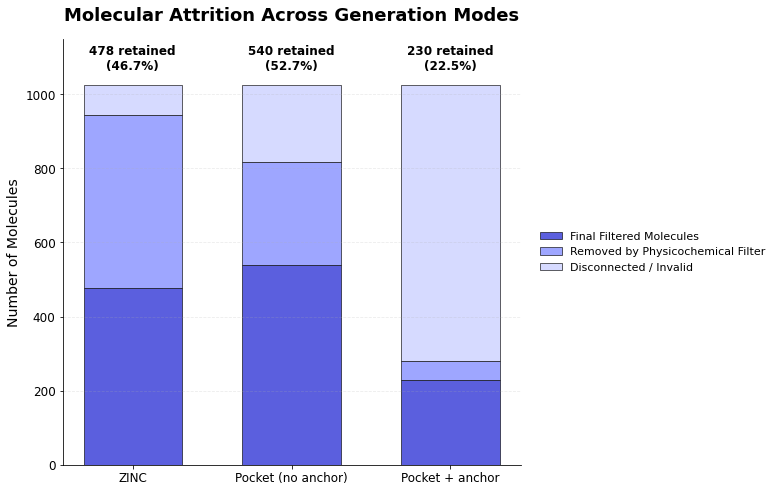

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# Better typography
# ---------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 12,
    "axes.titlesize": 18,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 11
})

# ---------------------------------------------------
# Data
# ---------------------------------------------------
df = pd.DataFrame({
    "Mode": [
        "ZINC",
        "Pocket (no anchor)",
        "Pocket + anchor"
    ],
    "Generated": [1024, 1024, 1024],
    "Connected": [943, 818, 279],
    "Filtered": [478, 540, 230]
})

# ---------------------------------------------------
# Attrition calculations
# ---------------------------------------------------
df["Disconnected"] = df["Generated"] - df["Connected"]
df["Filter_Removed"] = df["Connected"] - df["Filtered"]

# ---------------------------------------------------
# Soft blue/violet palette
# ---------------------------------------------------
COLORS = {
    "Filtered": "#5B5FDE",        # rich violet-blue
    "Filter_Removed": "#9EA6FF",  # soft periwinkle
    "Disconnected": "#D6DAFF"     # pale lavender-blue
}

# ---------------------------------------------------
# Plot
# ---------------------------------------------------
x = np.arange(len(df))
width = 0.62

fig, ax = plt.subplots(figsize=(11, 7))

# Base retained molecules
ax.bar(
    x,
    df["Filtered"],
    width,
    color=COLORS["Filtered"],
    edgecolor="black",
    linewidth=0.6,
    label="Final Filtered Molecules"
)

# Removed by filter
ax.bar(
    x,
    df["Filter_Removed"],
    width,
    bottom=df["Filtered"],
    color=COLORS["Filter_Removed"],
    edgecolor="black",
    linewidth=0.6,
    label="Removed by Physicochemical Filter"
)

# Disconnected/invalid
ax.bar(
    x,
    df["Disconnected"],
    width,
    bottom=df["Filtered"] + df["Filter_Removed"],
    color=COLORS["Disconnected"],
    edgecolor="black",
    linewidth=0.6,
    label="Disconnected / Invalid"
)

# ---------------------------------------------------
# Outside labels
# ---------------------------------------------------
for i in range(len(df)):

    total = df.loc[i, "Generated"]
    final = df.loc[i, "Filtered"]

    pct = (final / total) * 100

    ax.text(
        x[i],
        total + 35,
        f"{final} retained\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# ---------------------------------------------------
# Axis formatting
# ---------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(df["Mode"])

ax.set_ylabel("Number of Molecules")
ax.set_title(
    "Molecular Attrition Across Generation Modes",
    pad=18,
    fontweight="bold"
)

# nicer grid
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

# remove top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# give headroom for labels
ax.set_ylim(0, 1150)

# legend
ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)

plt.tight_layout()

# optional save
# plt.savefig("attrition_chart.png", dpi=300, bbox_inches="tight")

plt.show()

In [17]:
import plotly.graph_objects as go

# -----------------------------
# Data
# -----------------------------
labels = [
    "ZINC<br>Generated",
    "ZINC<br>Connected",
    "ZINC<br>Filtered",

    "Pocket<br>Generated",
    "Pocket<br>Connected",
    "Pocket<br>Filtered",

    "Pocket + Anchor<br>Generated",
    "Pocket + Anchor<br>Connected",
    "Pocket + Anchor<br>Filtered"
]

source = [0, 1, 3, 4, 6, 7]
target = [1, 2, 4, 5, 7, 8]

values = [
    1024, 478,
    1024, 540,
    1024, 230
]

# -----------------------------
# Colors
# -----------------------------
colors = [
    '#a6cee3', '#b2df8a', '#fb9a99', '#fdbf6f',
    '#cab2d6', '#ffff99', '#1f78b4', '#33a02c'
]

node_colors = [
    colors[0], colors[6], colors[6],
    colors[1], colors[7], colors[7],
    colors[4], '#9467bd', '#6a3d9a'
]

link_colors = [
    "rgba(31,120,180,0.30)",
    "rgba(31,120,180,0.65)",

    "rgba(51,160,44,0.30)",
    "rgba(51,160,44,0.65)",

    "rgba(148,103,189,0.30)",
    "rgba(106,61,154,0.75)"
]

# -----------------------------
# Sankey Diagram
# -----------------------------
fig = go.Figure(go.Sankey(
    arrangement="snap",

    node=dict(
        pad=28,
        thickness=26,
        line=dict(color="rgba(0,0,0,0.12)", width=1),

        label=labels,
        color=node_colors,

        hovertemplate='%{label}<extra></extra>'
    ),

    link=dict(
        source=source,
        target=target,
        value=values,
        color=link_colors,

        hovertemplate='Count: %{value}<extra></extra>'
    )
))

# -----------------------------
# Layout
# -----------------------------
fig.update_layout(
    title=dict(
        text="DiffLinker Generation and Filtering Pipeline",
        x=0.5,
        xanchor="center",
        font=dict(
            size=26,
            family="Arial"
        )
    ),

    font=dict(
        family="Arial",
        size=16,
        color="#222"
    ),

    paper_bgcolor="white",
    plot_bgcolor="white",

    width=1400,
    height=700,

    margin=dict(
        l=40,
        r=40,
        t=90,
        b=40
    )
)

# -----------------------------
# Save as HTML
# -----------------------------
fig.write_html(
    "clean_sankey.html",
    include_plotlyjs="cdn"
)

print("Saved as clean_sankey.html")

# Optional preview
fig.show()

Saved as clean_sankey.html


/home/rajnish/miniconda3/envs/difflinker/lib/python3.10/site-packages/plotly/io/_renderers.py:51: UserWarning: Plotly version >= 6 requires Jupyter Notebook >= 7 but you have 6.4.11 installed.
 To upgrade Jupyter Notebook, please run `pip install notebook --upgrade`.
  warnings.warn(


Found 818 XYZ files
                     Molecule       QED     LogP        SA
0  2output_221_Fragments_.xyz  0.136720 -0.78496  8.355009
1  2output_281_Fragments_.xyz  0.062803  0.77499  7.556551
2  2output_351_Fragments_.xyz  0.058233 -0.28975  6.707576
3  2output_418_Fragments_.xyz  0.127033 -0.79676  8.361083
4   1output_25_Fragments_.xyz  0.040763  2.33684  6.351296

Successfully processed: 818 molecules

Saved descriptor table as R_NA_P_1_descriptors.csv


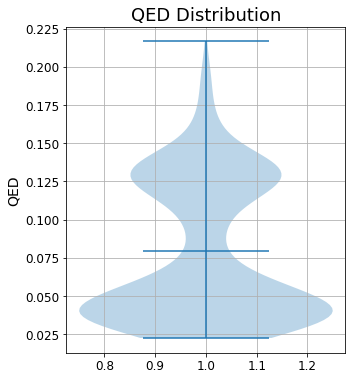

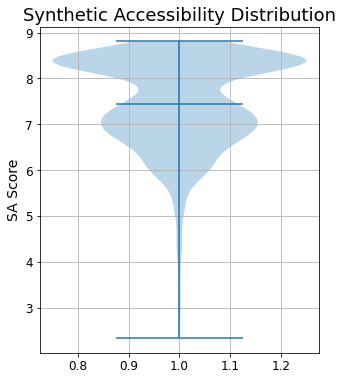

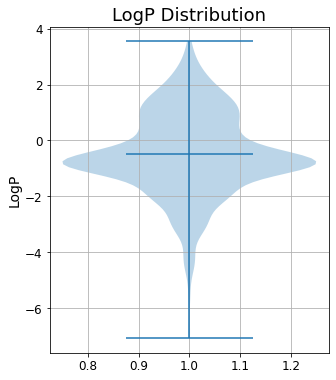

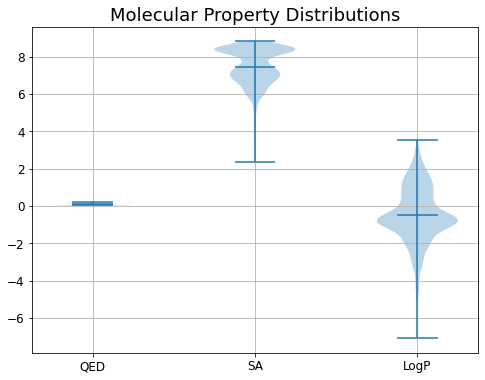

In [18]:
# ============================================================
# Violin Plots for QED, SA Score, and LogP from XYZ files
# ============================================================

# Install if needed:
# !pip install rdkit-pypi pandas matplotlib

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem
from rdkit.Chem import QED, Crippen, Descriptors
from rdkit.Chem import rdDetermineBonds
from rdkit.Chem import RDConfig

import sys

# ------------------------------------------------------------
# Add SA_Score path
# ------------------------------------------------------------

sys.path.append(os.path.join(RDConfig.RDContribDir, 'SA_Score'))
import sascorer

# ------------------------------------------------------------
# Folder containing XYZ files
# ------------------------------------------------------------

xyz_folder = "final_R_NA_P_1/"

xyz_files = glob.glob(os.path.join(xyz_folder, "*.xyz"))

print(f"Found {len(xyz_files)} XYZ files")

# ------------------------------------------------------------
# Function to convert XYZ -> RDKit molecule
# ------------------------------------------------------------

def xyz_to_mol(xyz_path):

    try:
        with open(xyz_path, "r") as f:
            xyz_block = f.read()

        mol = Chem.MolFromXYZBlock(xyz_block)

        if mol is None:
            return None

        # Only determine connectivity
        rdDetermineBonds.DetermineConnectivity(mol)

        # Try bond orders, but don't fail entire molecule
        try:
            rdDetermineBonds.DetermineBondOrders(mol)
        except:
            pass

        # Sanitize gently
        try:
            Chem.SanitizeMol(mol)
        except:
            pass

        return mol

    except Exception as e:
        print(f"Failed: {os.path.basename(xyz_path)} | {e}")
        return None
# ------------------------------------------------------------
# Calculate descriptors
# ------------------------------------------------------------

results = []

for file in xyz_files:

    mol = xyz_to_mol(file)

    if mol is None:
        continue

    try:
        qed = QED.qed(mol)
        logp = Crippen.MolLogP(mol)
        sa = sascorer.calculateScore(mol)

        results.append({
            "Molecule": os.path.basename(file),
            "QED": qed,
            "LogP": logp,
            "SA": sa
        })

    except Exception as e:
        print(f"Descriptor failed: {os.path.basename(file)} | {e}")

# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

df = pd.DataFrame(results)

print(df.head())
print(f"\nSuccessfully processed: {len(df)} molecules")

# ------------------------------------------------------------
# Save CSV
# ------------------------------------------------------------

df.to_csv("R_NA_P_1_descriptors.csv", index=False)

print("\nSaved descriptor table as R_NA_P_1_descriptors.csv")

# ============================================================
# VIOLIN PLOTS
# ============================================================

# ------------------------------------------------------------
# QED
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["QED"], showmeans=True)
plt.ylabel("QED")
plt.title("QED Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# SA Score
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["SA"], showmeans=True)
plt.ylabel("SA Score")
plt.title("Synthetic Accessibility Distribution")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# LogP
# ------------------------------------------------------------

plt.figure(figsize=(5,6))
plt.violinplot(df["LogP"], showmeans=True)
plt.ylabel("LogP")
plt.title("LogP Distribution")
plt.grid(True)
plt.show()

# ============================================================
# Combined Violin Plot
# ============================================================

plt.figure(figsize=(8,6))

data = [
    df["QED"],
    df["SA"],
    df["LogP"]
]

plt.violinplot(data, showmeans=True)

plt.xticks([1,2,3], ["QED", "SA", "LogP"])
plt.title("Molecular Property Distributions")
plt.grid(True)

plt.show()